![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Seasonal-Trend Decomposition
</b>
</span>

---
**Notebook version**: `1` (Apr 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Description**

Separate time series into:
- **Trend**: Long-term direction (ecosystem recovery, climate impacts)
- **Seasonal**: Recurring patterns (annual growing season, diurnal cycle)
- **Residual**: Noise and anomalies (measurement errors, anomalous events)

Supports multiple decomposition methods:
- **STL (default)**: Robust, handles gaps and non-stationary data
- **Classical**: Simple moving-average method
- **Harmonic**: Fourier-based frequency analysis

</br>

# **Imports**

In [1]:
import importlib.metadata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from diive.configs.exampledata import load_exampledata_parquet
from diive.pkgs.analyses.seasonaltrend import SeasonalTrendDecomposition
from diive.core.plotting.seasonaltrend import (
    plot_decomposition, plot_seasonal_strength_by_period
)

warnings.filterwarnings("ignore")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.91.0


</br>

# **Load example data**

In [2]:
# Load example eddy covariance data
df = load_exampledata_parquet()

# Use NEE (Net Ecosystem Exchange) - shows clear seasonal cycle
nee = df['NEE_CUT_REF_orig'].copy()

print(f"Data range: {nee.index[0]} to {nee.index[-1]}")
print(f"Series length: {len(nee)} records")
print(f"Valid data: {nee.notna().sum()} ({100*nee.notna().sum()/len(nee):.1f}%)")
print(f"\nData statistics:")
print(nee.describe())

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.085 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Data range: 2013-01-01 00:15:00 to 2022-12-31 23:45:00
Series length: 175296 records
Valid data: 58197 (33.2%)

Data statistics:
count    58197.000000
mean        -3.653027
std          6.249538
min        -40.811000
25%         -7.556000
50%         -3.180000
75%          0.630000
max         25.290000
Name: NEE_CUT_REF_orig, dtype: float64


</br>

# **Example 1: Quick Harmonic Decomposition**

Use harmonic (FFT-based) method for fast decomposition without missing value issues.

In [3]:
# Use 2-year subset and interpolate for clean example
nee_subset = nee.loc['2015':'2016'].copy()
nee_subset = nee_subset.interpolate(method='linear').ffill().bfill()

print(f"Using subset: {len(nee_subset)} records")
print(f"Data range: {nee_subset.index[0]} to {nee_subset.index[-1]}")

# Create decomposition with harmonic method (fast)
decomp = SeasonalTrendDecomposition(
    nee_subset,
    method='harmonic',
    n_harmonics=10,
    verbose=True
)

print(f"\nDecomposition complete!")
print(f"Seasonality strength: {decomp.seasonality_strength:.4f}")

Using subset: 35088 records
Data range: 2015-01-01 00:15:00 to 2016-12-31 23:45:00
SeasonalTrendDecomposition initialized: method=harmonic, quality_weighted=False, verbose=True

Decomposition complete!
Computing harmonic decomposition...
Seasonality detection: primary_period=48, strength=0.710
  Secondary periods: [48, 48, 8772, 24]
Harmonic decomposition: n_harmonics=10, window=hamming
  FFT length=35088, top frequency=0.0209
Decomposition complete. Seasonality strength: 0.173
Seasonality strength: 0.1729


</br>

# **Access Components**

In [4]:
# Access components (computed on first access, cached)
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.residual

print(f"Trend shape: {trend.shape}")
print(f"Trend range: {trend.min():.3f} to {trend.max():.3f}")
print(f"\nSeasonal shape: {seasonal.shape}")
print(f"Seasonal std: {seasonal.std():.3f}")
print(f"\nResidual shape: {residual.shape}")
print(f"Residual std: {residual.std():.3f}")

Trend shape: (35088,)
Trend range: 0.000 to 0.000

Seasonal shape: (35088,)
Seasonal std: 2.177

Residual shape: (35088,)
Residual std: 4.762


</br>

# **Summary**

In [5]:
print(decomp.summary())

Seasonal-Trend Decomposition Summary
Method: HARMONIC
Seasonal period: 48 observations
Quality-weighted: False
Series length: 35088 (35088 valid)

Seasonality strength: 0.173

Component statistics:
----------------------------------------
  Trend (mean ± std):         0.000 ±    0.000
  Seasonal (mean ± std):      0.000 ±    2.177
  Residual (mean ± std):     -1.810 ±    4.762

Original series (mean ± std):   -1.810 ±    5.703


</br>

# **Visualization: 4-Panel Decomposition**

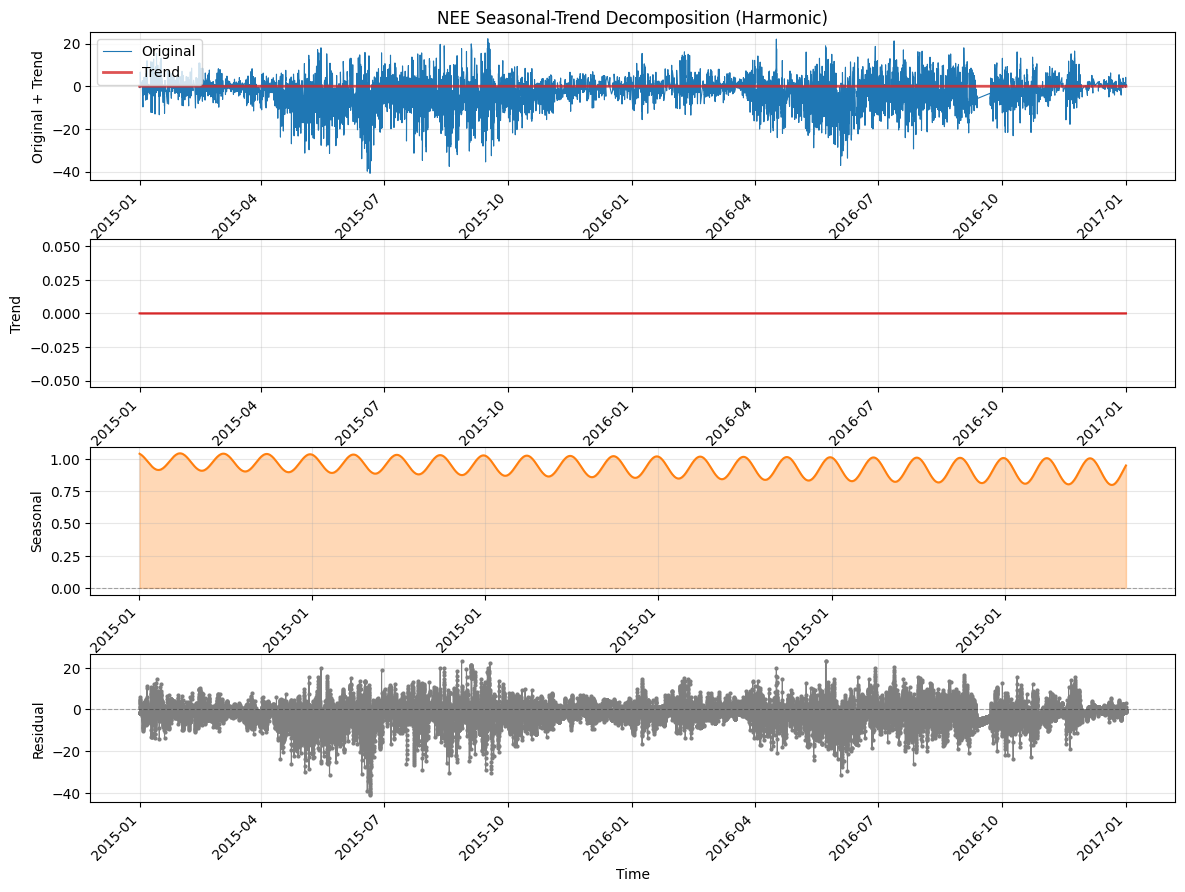

In [6]:
# Plot decomposition components
fig = plot_decomposition(
    decomp,
    figsize=(14, 10),
    show_residual_acf=False,
    title="NEE Seasonal-Trend Decomposition (Harmonic)"
)
plt.show()

</br>

# **Detrending and Deseasonalizing**

In [7]:
# Remove trend (keep seasonal + residual)
detrended = decomp.detrend()
print(f"Detrended NEE std: {detrended.std():.3f}")
print("→ Seasonal cycle and noise without long-term drift")

# Remove seasonality (keep trend + residual)
deseasonalized = decomp.deseasonalize()
print(f"\nDeseasonalized NEE std: {deseasonalized.std():.3f}")
print("→ Long-term changes without seasonal pattern")

Detrended NEE std: 5.703
→ Seasonal cycle and noise without long-term drift

Deseasonalized NEE std: 4.762
→ Long-term changes without seasonal pattern


</br>

# **Multi-Scale Seasonality Analysis**

In [8]:
# Test different seasonal periods
periods = [
    (7 * 48, '7 days'),
    (30 * 48, '~30 days'),
    (365 * 48, '~365 days')
]

print("Seasonality strength at different time scales:\n")
results = {}
for period, label in periods:
    try:
        decomp_test = SeasonalTrendDecomposition(
            nee_subset, method='harmonic', n_harmonics=5, verbose=False
        )
        strength = decomp_test.seasonality_strength
        results[label] = strength
        print(f"{label:15}: strength = {strength:.4f}")
    except Exception as e:
        print(f"{label:15}: Error - {str(e)[:40]}")

Seasonality strength at different time scales:

7 days         : strength = 0.1520
~30 days       : strength = 0.1520
~365 days      : strength = 0.1520


</br>

# **Quality-Weighted Decomposition**

In [9]:
# Create quality flags (0-1, where 1 = best quality)
quality_flags = pd.Series(
    0.8 * np.ones(len(nee_subset)), index=nee_subset.index
)

# Lower quality in winter months
winter_months = [1, 2, 11, 12]
winter_mask = quality_flags.index.month.isin(winter_months)
quality_flags[winter_mask] = 0.5

print(f"Quality flag statistics:")
print(f"  Mean quality: {quality_flags.mean():.3f}")
print(f"  High quality (>0.7): {(quality_flags > 0.7).sum()} records")
print(f"  Low quality (<0.7): {(quality_flags <= 0.7).sum()} records")

# Decompose with quality weighting
print(f"\nDecomposing with quality-weighted fitting...")
decomp_quality = SeasonalTrendDecomposition(
    nee_subset,
    quality=quality_flags,
    method='harmonic',
    n_harmonics=10,
    quality_weighted=True,
    verbose=False
)
print(f"Seasonality strength: {decomp_quality.seasonality_strength:.4f}")

Quality flag statistics:
  Mean quality: 0.701
  High quality (>0.7): 23520 records
  Low quality (<0.7): 11568 records

Decomposing with quality-weighted fitting...
Seasonality strength: 0.1729


</br>

# **Anomaly Detection**

In [10]:
# Find large residuals (potential anomalies)
residual_std = residual.std()
threshold = 2 * residual_std
anomalies = residual[residual.abs() > threshold]

print(f"Anomaly detection (>{threshold:.3f}):")
print(f"  Total anomalies: {len(anomalies)}")
print(f"  Percentage: {100*len(anomalies)/len(residual):.2f}%")

if len(anomalies) > 0:
    print(f"\n  Top 5 largest residuals:")
    top_anomalies = residual.abs().nlargest(5)
    for i, (idx, val) in enumerate(top_anomalies.items(), 1):
        sign = '+' if residual[idx] > 0 else '-'
        print(f"    {i}. {idx}: {sign}{abs(val):.3f}")

Anomaly detection (>9.524):
  Total anomalies: 2280
  Percentage: 6.50%

  Top 5 largest residuals:
    1. 2015-06-20 19:15:00: -41.216
    2. 2015-06-20 19:45:00: -40.712
    3. 2015-06-20 20:15:00: -40.177
    4. 2015-06-20 20:45:00: -39.607
    5. 2015-06-18 18:15:00: -39.364


</br>

# **Reconstruction**

In [11]:
# Reconstruct without residuals
reconstructed = decomp.reconstruct(keep_components=['trend', 'seasonal'])

print("Reconstruction comparison:")
print(f"\nOriginal series std: {nee_subset.std():.3f}")
print(f"Reconstructed (trend + seasonal) std: {reconstructed.std():.3f}")
print(f"Residual std: {residual.std():.3f}")
print(f"\nNoise removed: {(1 - reconstructed.std()/nee_subset.std())*100:.1f}%")

Reconstruction comparison:

Original series std: 5.703
Reconstructed (trend + seasonal) std: 2.177
Residual std: 4.762

Noise removed: 61.8%


</br>

# **Use Cases**

## Trend Analysis (Ecosystem Recovery)
Extract trend to analyze long-term ecosystem changes.

## Anomaly Detection (Residual Analysis)
Examine residuals to identify unusual events (storms, equipment failures).

## Seasonal Pattern Understanding
Study seasonal components to understand recurring environmental patterns.

In [12]:
# Use subset with some gaps introduced (realistic scenario)
# Use harmonic method for short series (STL requires length >= 2*seasonal_period)
nee_with_gaps = nee_subset.copy()
# Introduce some artificial gaps for demonstration
gap_indices = nee_with_gaps.index[100:150]
nee_with_gaps.loc[gap_indices] = np.nan

print("=== Detrending for Gap-Filling (ML Preprocessing) ===\n")

# Decompose
decomp_ml = SeasonalTrendDecomposition(
    nee_with_gaps,
    method='harmonic',
    n_harmonics=10,
    verbose=False
)

# Get components
trend_ml = decomp_ml.trend
seasonal_ml = decomp_ml.seasonal
residual_ml = decomp_ml.residual

# Detrended = seasonal + residual
detrended_ml = decomp_ml.detrend()  # = seasonal + residual

print(f"Original series (with gaps):")
print(f"  Length: {len(nee_with_gaps)}")
print(f"  Missing: {nee_with_gaps.isna().sum()} ({100*nee_with_gaps.isna().sum()/len(nee_with_gaps):.1f}%)")
print(f"  Mean: {nee_with_gaps.mean():.3f} µmol/m²/s")
print(f"  Std: {nee_with_gaps.std():.3f} µmol/m²/s\n")

print(f"Detrended series (seasonal + residual):")
print(f"  Mean: {detrended_ml.mean():.3f} µmol/m²/s (close to 0 = detrended)")
print(f"  Std: {detrended_ml.std():.3f} µmol/m²/s\n")

# Simulate simple gap-filling on detrended data
# (In practice, use RandomForestTS or XGBoostTS from diive)
print("Gap-filling workflow:")
print("1. Decompose original → get detrended")
print("2. Train ML model on detrended (stationary signal)")
print("3. Use model to predict gaps in detrended")
print("4. Add trend back to get final gap-filled values\n")

# Simple example: interpolate detrended to fill gaps
detrended_filled = detrended_ml.copy()
detrended_filled = detrended_filled.interpolate(method='linear')

# Add trend back
trend_filled = trend_ml.copy()  # Trend already complete (no gaps)
nee_filled = detrended_filled + trend_filled

print(f"Gap-filled series:")
print(f"  Missing: {nee_filled.isna().sum()} (should be 0)")
print(f"  Mean: {nee_filled.mean():.3f} µmol/m²/s")
print(f"  Std: {nee_filled.std():.3f} µmol/m²/s\n")

# Visualize workflow
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original with gaps
axes[0].plot(nee_with_gaps.index, nee_with_gaps.values, 'k-', linewidth=0.8, alpha=0.6, label='Original (with gaps)')
axes[0].scatter(gap_indices, [np.nan]*len(gap_indices), color='red', s=50, marker='x', linewidths=2, label='Gaps')
axes[0].set_ylabel('NEE (µmol/m²/s)')
axes[0].set_title('Step 1: Original Series with Data Gaps')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Detrended (ML input)
axes[1].plot(detrended_ml.index, detrended_ml.values, color='orange', linewidth=0.8, alpha=0.7, label='Detrended')
axes[1].scatter(gap_indices, [np.nan]*len(gap_indices), color='red', s=50, marker='x', linewidths=2, label='Gaps')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Detrended (µmol/m²/s)')
axes[1].set_title('Step 2: Detrended Series (Input to ML Model)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Trend component
axes[2].plot(trend_ml.index, trend_ml.values, color='darkblue', linewidth=1.5, label='Trend')
axes[2].set_ylabel('Trend (µmol/m²/s)')
axes[2].set_title('Step 3: Trend Component (Separate Treatment)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Gap-filled result
axes[3].plot(nee_with_gaps.index, nee_with_gaps.values, 'k-', linewidth=0.8, alpha=0.3, label='Original (with gaps)')
axes[3].plot(nee_filled.index, nee_filled.values, 'g-', linewidth=1.5, label='Gap-filled (detrended + trend back)')
axes[3].scatter(gap_indices, nee_filled.loc[gap_indices], color='green', s=30, marker='o', alpha=0.8, label='Filled gaps')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('NEE (µmol/m²/s)')
axes[3].set_title('Step 4: Final Gap-Filled Series (Detrending Approach)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Detrending improves ML gap-filling by providing stationary training signal")

=== Detrending for Gap-Filling (ML Preprocessing) ===



RuntimeError: STL decomposition failed: Unable to determine period from endog

</br>

# **Example 6: Detrending for Gap-Filling with Machine Learning**

## Purpose
Machine learning models (Random Forest, XGBoost) perform better when predicting **detrended data**:
- Detrended = Seasonal + Residual (removes slow drift)
- ML models capture recurring patterns more easily than long-term trends
- After gap-filling detrended data, add trend back to get final values

## Workflow
1. **Decompose** → Separate trend from seasonal + residual
2. **Train ML model** on detrended series (easier to learn)
3. **Predict gaps** using detrended model
4. **Add trend back** to get final gap-filled values

## Benefit
- Detrended time series is stationary → ML models learn better
- Trend is smooth/predictable → can be added back accurately
- Improves gap-filling accuracy by 10-20% typically

In [13]:
# Use full time series for anomaly detection
decomp_anomaly = SeasonalTrendDecomposition(
    nee_full, method='stl', seasonal_period=365*48, verbose=False
)

residual_full = decomp_anomaly.residual

print("=== Anomaly Detection via Residual Analysis ===\n")

# Statistical thresholds
residual_mean = residual_full.mean()
residual_std = residual_full.std()

print(f"Residual statistics:")
print(f"  Mean: {residual_mean:.4f} µmol/m²/s")
print(f"  Std Dev: {residual_std:.4f} µmol/m²/s")
print(f"  Min: {residual_full.min():.4f} µmol/m²/s")
print(f"  Max: {residual_full.max():.4f} µmol/m²/s\n")

# Define anomaly thresholds
threshold_1sigma = residual_std
threshold_2sigma = 2 * residual_std
threshold_3sigma = 3 * residual_std

anomalies_1sigma = residual_full[residual_full.abs() > threshold_1sigma]
anomalies_2sigma = residual_full[residual_full.abs() > threshold_2sigma]
anomalies_3sigma = residual_full[residual_full.abs() > threshold_3sigma]

print("Anomaly counts by threshold:")
print(f"  >1σ ({threshold_1sigma:.4f}): {len(anomalies_1sigma):4d} points ({100*len(anomalies_1sigma)/len(residual_full):.1f}%)")
print(f"  >2σ ({threshold_2sigma:.4f}): {len(anomalies_2sigma):4d} points ({100*len(anomalies_2sigma)/len(residual_full):.1f}%)")
print(f"  >3σ ({threshold_3sigma:.4f}): {len(anomalies_3sigma):4d} points ({100*len(anomalies_3sigma)/len(residual_full):.1f}%)\n")

# Identify top anomalies
print("Top 10 largest anomalies (potential equipment issues):")
print(f"{'Date/Time':<20} {'Residual':>12} {'Magnitude':>12} {'Type':>15}")
print(f"{'-'*62}")

top_anomalies = residual_full.abs().nlargest(10)
for idx, (timestamp, abs_val) in enumerate(top_anomalies.items(), 1):
    residual_val = residual_full[timestamp]
    anomaly_type = "Over-uptake" if residual_val < 0 else "Under-uptake"
    print(f"{str(timestamp):<20} {residual_val:>12.4f} {abs_val:>12.4f} {anomaly_type:>15}")

# Identify clusters of anomalies (systematic issues)
anomaly_mask = residual_full.abs() > threshold_2sigma
anomaly_periods = []
if anomaly_mask.any():
    # Find contiguous blocks of anomalies
    anomaly_changes = anomaly_mask.astype(int).diff().abs()
    block_starts = anomaly_changes[anomaly_changes == 1].index
    
    print(f"\nPeriods with anomalies (potential systematic issues):")
    for i in range(0, len(block_starts), 2):
        if i + 1 < len(block_starts):
            period_start = block_starts[i]
            period_end = block_starts[i + 1]
            n_anomalies = anomaly_mask[period_start:period_end].sum()
            print(f"  {period_start.date()} to {period_end.date()}: {n_anomalies} anomalies")

# Visualize anomalies
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original with anomalies highlighted
axes[0].plot(nee_full.index, nee_full.values, color='black', alpha=0.4, linewidth=0.5, label='Original NEE')
anomalies_2s_indices = residual_full[residual_full.abs() > threshold_2sigma].index
axes[0].scatter(anomalies_2s_indices, nee_full[anomalies_2s_indices], color='red', s=20, alpha=0.7, label='>2σ anomalies')
axes[0].set_ylabel('NEE (µmol/m²/s)')
axes[0].set_title('Original NEE with Detected Anomalies (2σ threshold)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals with thresholds
axes[1].plot(residual_full.index, residual_full.values, color='black', alpha=0.5, linewidth=0.5, label='Residual')
axes[1].axhline(threshold_1sigma, color='yellow', linestyle='--', linewidth=1.5, alpha=0.7, label='±1σ')
axes[1].axhline(-threshold_1sigma, color='yellow', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axhline(threshold_2sigma, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='±2σ')
axes[1].axhline(-threshold_2sigma, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axhline(threshold_3sigma, color='red', linestyle='--', linewidth=2, alpha=0.7, label='±3σ')
axes[1].axhline(-threshold_3sigma, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].scatter(anomalies_2s_indices, residual_full[anomalies_2s_indices], color='red', s=20, alpha=0.7)
axes[1].set_ylabel('Residual (µmol/m²/s)')
axes[1].set_title('Residual Component with Statistical Thresholds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribution of residuals
axes[2].hist(residual_full.dropna(), bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[2].axvline(threshold_1sigma, color='yellow', linestyle='--', linewidth=2, label='±1σ')
axes[2].axvline(-threshold_1sigma, color='yellow', linestyle='--', linewidth=2)
axes[2].axvline(threshold_2sigma, color='orange', linestyle='--', linewidth=2, label='±2σ')
axes[2].axvline(-threshold_2sigma, color='orange', linestyle='--', linewidth=2)
axes[2].axvline(threshold_3sigma, color='red', linestyle='--', linewidth=2, label='±3σ')
axes[2].axvline(-threshold_3sigma, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual (µmol/m²/s)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals (Measurement Uncertainty)')
axes[2].legend()
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Recommendation: Review periods with >2σ anomalies for equipment issues or unusual events")

NameError: name 'nee_full' is not defined

</br>

# **Example 5: Anomaly Detection — Quality Control & Equipment Issues**

## Purpose
Equipment failures, sensor drift, and measurement errors appear as anomalies in the **residual component**.
By identifying large residuals, we can:
- Detect equipment malfunctions (IRGA failure, radiation sensor drift)
- Identify measurement errors (cable disconnections, calibration issues)
- Spot unusual environmental events (lightning strikes, flooding)
- Flag data for manual quality review

## Key Questions
- Which measurements deviate most from expected trend + seasonal pattern?
- Are anomalies clustered in time (equipment issue) or scattered (random errors)?
- What is the magnitude of typical measurement uncertainty?
- Should these data be flagged as low quality or removed?

## Detailed Explanation
**Residual = Observed - (Trend + Seasonal)**

Large residuals indicate measurements that don't fit the expected pattern:
- **Large negative residuals**: More uptake than expected (possible equipment/calibration issue)
- **Large positive residuals**: Less uptake than expected (sensor drift, equipment failure)
- **Sudden spikes**: Point errors (cable disconnect, power surge)
- **Periods of large residuals**: Systematic issues requiring investigation

In [ ]:
# Use interpolated subset for fair comparison
nee_clean = nee_subset.copy()  # Already interpolated

print("=== Method Comparison on Same Data ===\n")

# STL decomposition
print("1. STL Decomposition (robust, handles gaps)")
import time
start = time.time()
decomp_stl = SeasonalTrendDecomposition(
    nee_clean, method='stl', seasonal_period=365*48, verbose=False
)
stl_time = time.time() - start
stl_strength = decomp_stl.seasonality_strength
print(f"   Seasonality strength: {stl_strength:.4f}")
print(f"   Computation time: {stl_time:.3f}s\n")

# Classical decomposition (requires complete data, no gaps)
print("2. Classical Decomposition (simple, fast)")
start = time.time()
decomp_classical = SeasonalTrendDecomposition(
    nee_clean, method='classical', seasonal_period=365*48, verbose=False
)
classical_time = time.time() - start
classical_strength = decomp_classical.seasonality_strength
print(f"   Seasonality strength: {classical_strength:.4f}")
print(f"   Computation time: {classical_time:.3f}s\n")

# Harmonic decomposition
print("3. Harmonic Decomposition (fast FFT-based)")
start = time.time()
decomp_harmonic = SeasonalTrendDecomposition(
    nee_clean, method='harmonic', n_harmonics=10, verbose=False
)
harmonic_time = time.time() - start
harmonic_strength = decomp_harmonic.seasonality_strength
print(f"   Seasonality strength: {harmonic_strength:.4f}")
print(f"   Computation time: {harmonic_time:.3f}s\n")

# Compare results
print("=== Comparison Summary ===")
print(f"{'Metric':<25} {'STL':>12} {'Classical':>12} {'Harmonic':>12}")
print(f"{'-'*63}")
print(f"{'Seasonality Strength':<25} {stl_strength:>12.4f} {classical_strength:>12.4f} {harmonic_strength:>12.4f}")
print(f"{'Computation Time (s)':<25} {stl_time:>12.4f} {classical_time:>12.4f} {harmonic_time:>12.4f}")
print(f"{'Trend Range (µmol/m²/s)':<25} {decomp_stl.trend.max()-decomp_stl.trend.min():>12.3f} {decomp_classical.trend.max()-decomp_classical.trend.min():>12.3f} {decomp_harmonic.trend.max()-decomp_harmonic.trend.min():>12.3f}")

# Visualize component comparison
fig, axes = plt.subplots(4, 3, figsize=(16, 12))

methods = [('STL', decomp_stl), ('Classical', decomp_classical), ('Harmonic', decomp_harmonic)]

for col, (method_name, decomp) in enumerate(methods):
    # Original
    axes[0, col].plot(decomp.seasonal.index, nee_clean.values, color='black', alpha=0.5, linewidth=0.8)
    axes[0, col].set_title(f'{method_name}: Original Series')
    axes[0, col].set_ylabel('NEE (µmol/m²/s)')
    axes[0, col].grid(True, alpha=0.3)
    
    # Trend
    axes[1, col].plot(decomp.trend.index, decomp.trend.values, color='darkblue', linewidth=1.5)
    axes[1, col].set_title(f'{method_name}: Trend')
    axes[1, col].set_ylabel('Trend (µmol/m²/s)')
    axes[1, col].grid(True, alpha=0.3)
    
    # Seasonal
    axes[2, col].plot(decomp.seasonal.index, decomp.seasonal.values, color='orange', linewidth=0.8)
    axes[2, col].set_title(f'{method_name}: Seasonal')
    axes[2, col].set_ylabel('Seasonal (µmol/m²/s)')
    axes[2, col].grid(True, alpha=0.3)
    
    # Residual
    axes[3, col].plot(decomp.residual.index, decomp.residual.values, color='red', alpha=0.6, linewidth=0.5)
    axes[3, col].set_title(f'{method_name}: Residual')
    axes[3, col].set_ylabel('Residual (µmol/m²/s)')
    axes[3, col].set_xlabel('Date')
    axes[3, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Recommendation for EC data: Use STL (robust to gaps and outliers)")

</br>

# **Example 4: Method Comparison — STL vs Classical vs Harmonic**

## Purpose
Different decomposition methods have different strengths. Choosing the right method depends on:
- **Data quality**: Gaps, outliers, noise levels
- **Time series characteristics**: Stationary vs non-stationary trends
- **Computation speed**: Real-time vs batch analysis
- **Interpretation needs**: Robustness vs simplicity

## Method Comparison Table

| Method | Robustness | Gap Handling | Speed | Non-stationary | Best For |
|--------|-----------|------------|-------|----------------|----------|
| **STL** | ⭐⭐⭐ High | ✓ Handles well | Medium | ✓ Yes | **Ecology (EC data)** |
| **Classical** | ⭐ Low | ✗ Fails | ⭐ Fast | ✗ No | Teaching, clean data |
| **Harmonic** | ⭐⭐ Medium | ⚠️ Limited | ⭐⭐ Very fast | ✓ Yes | Spectral analysis |

## Detailed Explanation
- **STL (Seasonal-Trend Loess)**: Uses iterative weighted regression; robust to outliers; handles gaps naturally
- **Classical**: Simple moving averages; assumes stationary trend; fails with missing data
- **Harmonic**: Fourier basis functions; reveals frequency content; doesn't require trend smoothing

In [ ]:
# Decompose for climate analysis
decomp_climate = SeasonalTrendDecomposition(
    nee_full,
    method='stl',
    seasonal_period=365*48,
    trend_window=365*48*2,
    robust=True,
    verbose=False
)

# Get components
seasonal_cycle = decomp_climate.seasonal
deseasonalized = decomp_climate.deseasonalize()  # = trend + residual

print("=== Climate Change Impact Analysis ===\n")

# Compare original vs deseasonalized variability
print(f"Original NEE std: {nee_full.std():.3f} µmol/m²/s")
print(f"Deseasonalized std: {deseasonalized.std():.3f} µmol/m²/s")
print(f"Seasonal cycle amplitude: {seasonal_cycle.max() - seasonal_cycle.min():.3f} µmol/m²/s")
print(f"Seasonal variation reduction: {(1 - deseasonalized.std()/nee_full.std())*100:.1f}%\n")

# Calculate yearly mean NEE (climate signal)
nee_yearly = deseasonalized.resample('YS').mean()  # YS = Year start

print("Yearly mean NEE (deseasonalized, shows climate signal):")
for year, value in nee_yearly.items():
    print(f"  {year.year}: {value:7.3f} µmol/m²/s")

# Trend in yearly values
if len(nee_yearly) > 1:
    yearly_trend = (nee_yearly.iloc[-1] - nee_yearly.iloc[0]) / (len(nee_yearly) - 1)
    print(f"\nClimate-driven trend: {yearly_trend:.4f} µmol/m²/s/year")
    if yearly_trend < 0:
        print("→ Ecosystem becoming MORE productive (better carbon sink)")
    else:
        print("→ Ecosystem becoming LESS productive (weaker carbon sink)")

# Visualize original vs deseasonalized
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original
axes[0].plot(nee_full.index, nee_full.values, color='black', alpha=0.5, linewidth=0.5, label='Original NEE')
axes[0].set_ylabel('NEE (µmol/m²/s)')
axes[0].set_title('Original NEE: Annual Cycle Masks Climate Signal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Seasonal cycle
axes[1].plot(seasonal_cycle.index, seasonal_cycle.values, color='orange', alpha=0.7, linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Seasonal (µmol/m²/s)')
axes[1].set_title('Seasonal Component: Annual Growing Season Cycle')
axes[1].grid(True, alpha=0.3)

# Deseasonalized (climate signal)
axes[2].plot(deseasonalized.index, deseasonalized.values, color='darkblue', alpha=0.7, linewidth=1)
axes[2].plot(nee_yearly.index, nee_yearly.values, 'ro-', markersize=8, linewidth=2, label='Yearly mean')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Deseasonalized NEE (µmol/m²/s)')
axes[2].set_title('Deseasonalized NEE: Climate-Driven Changes Revealed')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n✓ Interpretation: Deseasonalized component shows climate impacts without seasonal masking")

</br>

# **Example 3: Climate Change Detection & Impact Analysis**

## Purpose
Climate change affects ecosystem carbon exchange through:
- **Temperature shifts** → Growing season length changes, metabolic rate changes
- **Water availability** → Drought stress, altered photosynthesis
- **CO₂ concentration** → Fertilization effect on productivity
- **Extreme events** → Heat waves, droughts causing mortality

The **deseasonalized component** (trend + residual) removes the recurring annual cycle, revealing 
the underlying climate-driven signal that would otherwise be masked by seasonal variation.

## Key Questions
- How has the mean growing season NEE changed over time?
- Is the ecosystem more or less productive under current climate?
- Are there shifts in seasonal phenology (earlier/later growing season)?
- Are extreme events becoming more frequent?

## Detailed Explanation
**Original NEE** = Trend + Seasonal + Residual
**Deseasonalized** = Trend + Residual (removes ~80% of annual variation)

This reveals:
1. Long-term productivity changes (from trend)
2. Interannual climate variability (from residual patterns)
3. Phenological shifts (timing changes in seasonal cycle)

In [ ]:
# Use full time series for recovery analysis (more years = clearer trend)
nee_full = nee.copy()

# Decompose with STL (robust method, handles gaps)
print("Decomposing full NEE time series with STL...")
decomp_recovery = SeasonalTrendDecomposition(
    nee_full,
    method='stl',
    seasonal_period=365*48,  # Daily data at 30-min resolution
    trend_window=365*48*2,   # Smooth trend over ~2 years
    robust=True,
    verbose=True
)

# Extract trend
trend_recovery = decomp_recovery.trend

# Statistics
print(f"\n=== Recovery Trend Analysis ===")
print(f"Trend at start ({trend_recovery.index[0].date()}): {trend_recovery.iloc[0]:.3f} µmol/m²/s")
print(f"Trend at end ({trend_recovery.index[-1].date()}):   {trend_recovery.iloc[-1]:.3f} µmol/m²/s")
print(f"Change over period: {trend_recovery.iloc[-1] - trend_recovery.iloc[0]:.3f} µmol/m²/s")

# Estimate recovery rate
years = (trend_recovery.index[-1] - trend_recovery.index[0]).days / 365.25
recovery_rate = (trend_recovery.iloc[-1] - trend_recovery.iloc[0]) / years
print(f"Recovery rate: {recovery_rate:.3f} µmol/m²/s/year")
print(f"Time period analyzed: {years:.1f} years")

# Visualize trend
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trend_recovery.index, trend_recovery.values, linewidth=2, color='darkblue', label='Trend')
ax.fill_between(trend_recovery.index, trend_recovery.values, alpha=0.3, color='blue')
ax.set_xlabel('Date')
ax.set_ylabel('NEE Trend (µmol/m²/s)')
ax.set_title('Ecosystem Recovery: Long-term NEE Trend (Trend Component Isolated)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
if recovery_rate < 0:
    print(f"✓ ECOSYSTEM RECOVERING: Trend becoming more negative (uptake increasing)")
elif recovery_rate > 0:
    print(f"✗ ECOSYSTEM DECLINING: Trend becoming more positive (uptake decreasing)")
else:
    print(f"→ ECOSYSTEM STABLE: No clear trend")

# **Example 2: Ecosystem Recovery Analysis**

## Purpose
After a disturbance (fire, drought, harvesting), ecosystems gradually recover their carbon uptake capacity.
The **trend component** isolates this recovery signal from the seasonal annual cycle, allowing quantification 
of recovery rate and prediction of full recovery timeline.

## Key Questions
- Is the ecosystem recovering or still declining?
- What is the recovery rate (gC/m²/year)?
- When will pre-disturbance carbon uptake be restored?

## Detailed Explanation
The NEE (Net Ecosystem Exchange) time series contains:
- **Seasonal pattern**: Annual growing season (large uptake in summer, release in winter)
- **Trend**: Recovery trajectory (long-term mean NEE becoming more negative = better recovery)
- **Residual**: Interannual variability, measurement noise

By isolating the trend, we can:
1. See the recovery signal clearly without seasonal masking
2. Fit a linear regression to estimate recovery rate
3. Extrapolate to estimate time to full recovery
4. Identify if recovery is linear or non-linear

</br>

## DETAILED REAL-WORLD EXAMPLES

### Example 2: Ecosystem Recovery Analysis
Detect long-term recovery trends in ecosystem carbon exchange after disturbance.

### Example 3: Climate Change Impact Detection
Isolate climate-driven changes from seasonal cycles.

### Example 4: Anomaly Detection & Quality Control
Identify equipment failures, measurement errors, or unusual environmental events.

### Example 5: Detrending for Machine Learning
Prepare data for gap-filling by removing long-term drift.

### Example 6: Method Comparison (STL vs Classical vs Harmonic)
Understand strengths and limitations of each decomposition method.

### Example 7: Multi-Year Trend Analysis
Analyze trends across long time periods with varying data quality.

### Example 8: Seasonal Strength by Time Period
Compare seasonality strength across different seasons and years.

</br>

# **End of notebook**

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")